# LeetCode #115: Distinct Subsequences

https://leetcode.com/problems/distinct-subsequences/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursion (naive) | O(2^m) | O(m) | Exponential, TLE |
| Memoization (Top-down DP) | O(m×n) | O(m×n) | Cache subproblems |
| **DP Table (Bottom-up)** | **O(m×n)** | **O(m×n)** | **Optimal — iterative, no stack** |

## Understanding the Method

We use a 2D DP table where `dp[i][j]` = number of distinct subsequences of `s[:i]` that equal `t[:j]`.

- **Base case:** `dp[i][0] = 1` for all `i` — the empty string `t` can always be formed one way.
- **Transition:** If `s[i-1] == t[j-1]`, we can either use this character (`dp[i-1][j-1]`) or skip it (`dp[i-1][j]`). Otherwise, we must skip (`dp[i-1][j]`).
- **Answer:** `dp[m][n]` where m = len(s), n = len(t).

## Constraints

- `1 <= s.length, t.length <= 1000`
- `s` and `t` consist of English letters only.
- Answer fits in a 32-bit integer.

## Solutions

### C#

In [ ]:
public class Solution {
    public int NumDistinct(string s, string t) {
        int m = s.Length, n = t.Length;
        long[,] dp = new long[m + 1, n + 1];
        for (int i = 0; i <= m; i++) dp[i, 0] = 1;
        for (int i = 1; i <= m; i++) {
            for (int j = 1; j <= n; j++) {
                dp[i, j] = dp[i - 1, j];
                if (s[i - 1] == t[j - 1])
                    dp[i, j] += dp[i - 1, j - 1];
            }
        }
        return (int)dp[m, n];
    }
}

### Python

In [ ]:
class Solution:
    def numDistinct(self, s: str, t: str) -> int:
        m, n = len(s), len(t)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = 1
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                dp[i][j] = dp[i - 1][j]
                if s[i - 1] == t[j - 1]:
                    dp[i][j] += dp[i - 1][j - 1]
        return dp[m][n]

### Go

In [ ]:
func numDistinct(s string, t string) int {
    m, n := len(s), len(t)
    dp := make([][]int, m+1)
    for i := range dp {
        dp[i] = make([]int, n+1)
        dp[i][0] = 1
    }
    for i := 1; i <= m; i++ {
        for j := 1; j <= n; j++ {
            dp[i][j] = dp[i-1][j]
            if s[i-1] == t[j-1] {
                dp[i][j] += dp[i-1][j-1]
            }
        }
    }
    return dp[m][n]
}

### Rust

In [ ]:
impl Solution {
    pub fn num_distinct(s: String, t: String) -> i32 {
        let s: Vec<u8> = s.bytes().collect();
        let t: Vec<u8> = t.bytes().collect();
        let (m, n) = (s.len(), t.len());
        let mut dp = vec![vec![0u64; n + 1]; m + 1];
        for i in 0..=m { dp[i][0] = 1; }
        for i in 1..=m {
            for j in 1..=n {
                dp[i][j] = dp[i-1][j];
                if s[i-1] == t[j-1] {
                    dp[i][j] += dp[i-1][j-1];
                }
            }
        }
        dp[m][n] as i32
    }
}

## Example Scenarios

### 1. Common Case — s = "rabbbit", t = "rabbit"
**Input:** `s = "rabbbit", t = "rabbit"`

Three 'b's in s, need two for t's "bb": $\binom{3}{2} = 3$ ways. The DP table shows how $dp[i][j]$ accumulates from $dp[i-1][j-1]$ (use character) $+ dp[i-1][j]$ (skip character) when $s[i] = t[j]$.

*Why tricky:* Happy-path case demonstrating the core DP recurrence with repeated characters.

**Output:** `3`

### 2. Slightly Complex — s = "babgbag", t = "bag"
**Input:** `s = "babgbag", t = "bag"`

Multiple overlapping positions: 'b' at indices 0, 2, 4; 'a' at 1, 5; 'g' at 3, 6. The DP values grow non-obviously: $dp[7][3] = 5$ ways. Each character position can pair with multiple subsequent positions.

*Why tricky:* Overlapping character positions create a combinatorial explosion that the DP table tracks correctly.

**Output:** `5`

### 3. Edge Case: Time Factor — s = "a" $\times$ 1000, t = "a" $\times$ 500
**Input:** `s = "aaa...a"` (1000 a's), `t = "aaa...a"` (500 a's)

Every character matches ($s[i] = t[j]$ always), so every DP cell executes the more expensive branch: $dp[i][j] = dp[i-1][j-1] + dp[i-1][j]$. Table size $= 1001 \times 501 = 501{,}501$ cells. Answer $= \binom{1000}{500}$, which overflows 32-bit integers.

*Why tricky:* Worst-case DP fill time — every cell takes the match branch. Result requires 64-bit integers or big-integer handling.

**Output:** `C(1000, 500)` (astronomically large)

### 4. Edge Case: Space Factor — s and t Both Length 1000
**Input:** `s = "a" * 1000, t = "a" * 1000`

DP table is $1001 \times 1001 = 1{,}002{,}001$ cells at 8 bytes each $\approx 8$ MB. The answer is trivially 1 (only one way: use every character). A rolling 1D array optimization would reduce space to $O(n)$.

*Why tricky:* Maximum possible space consumption. Tests memory limits even though the answer is trivially 1.

**Output:** `1`

### 5. Almost-Impossible but Plausible — t Longer Than s
**Input:** `s = "abc", t = "abcd"`

Since $|t| > |s|$, no subsequence of s can equal t. The DP table's last column stays 0 because 'd' never appears in s. The algorithm handles this without a special-case check — the recurrence naturally yields $dp[3][4] = 0$.

*Why tricky:* Boundary condition where $\text{len}(t) > \text{len}(s)$. The DP correctly returns 0 without needing an early exit.

**Output:** `0`

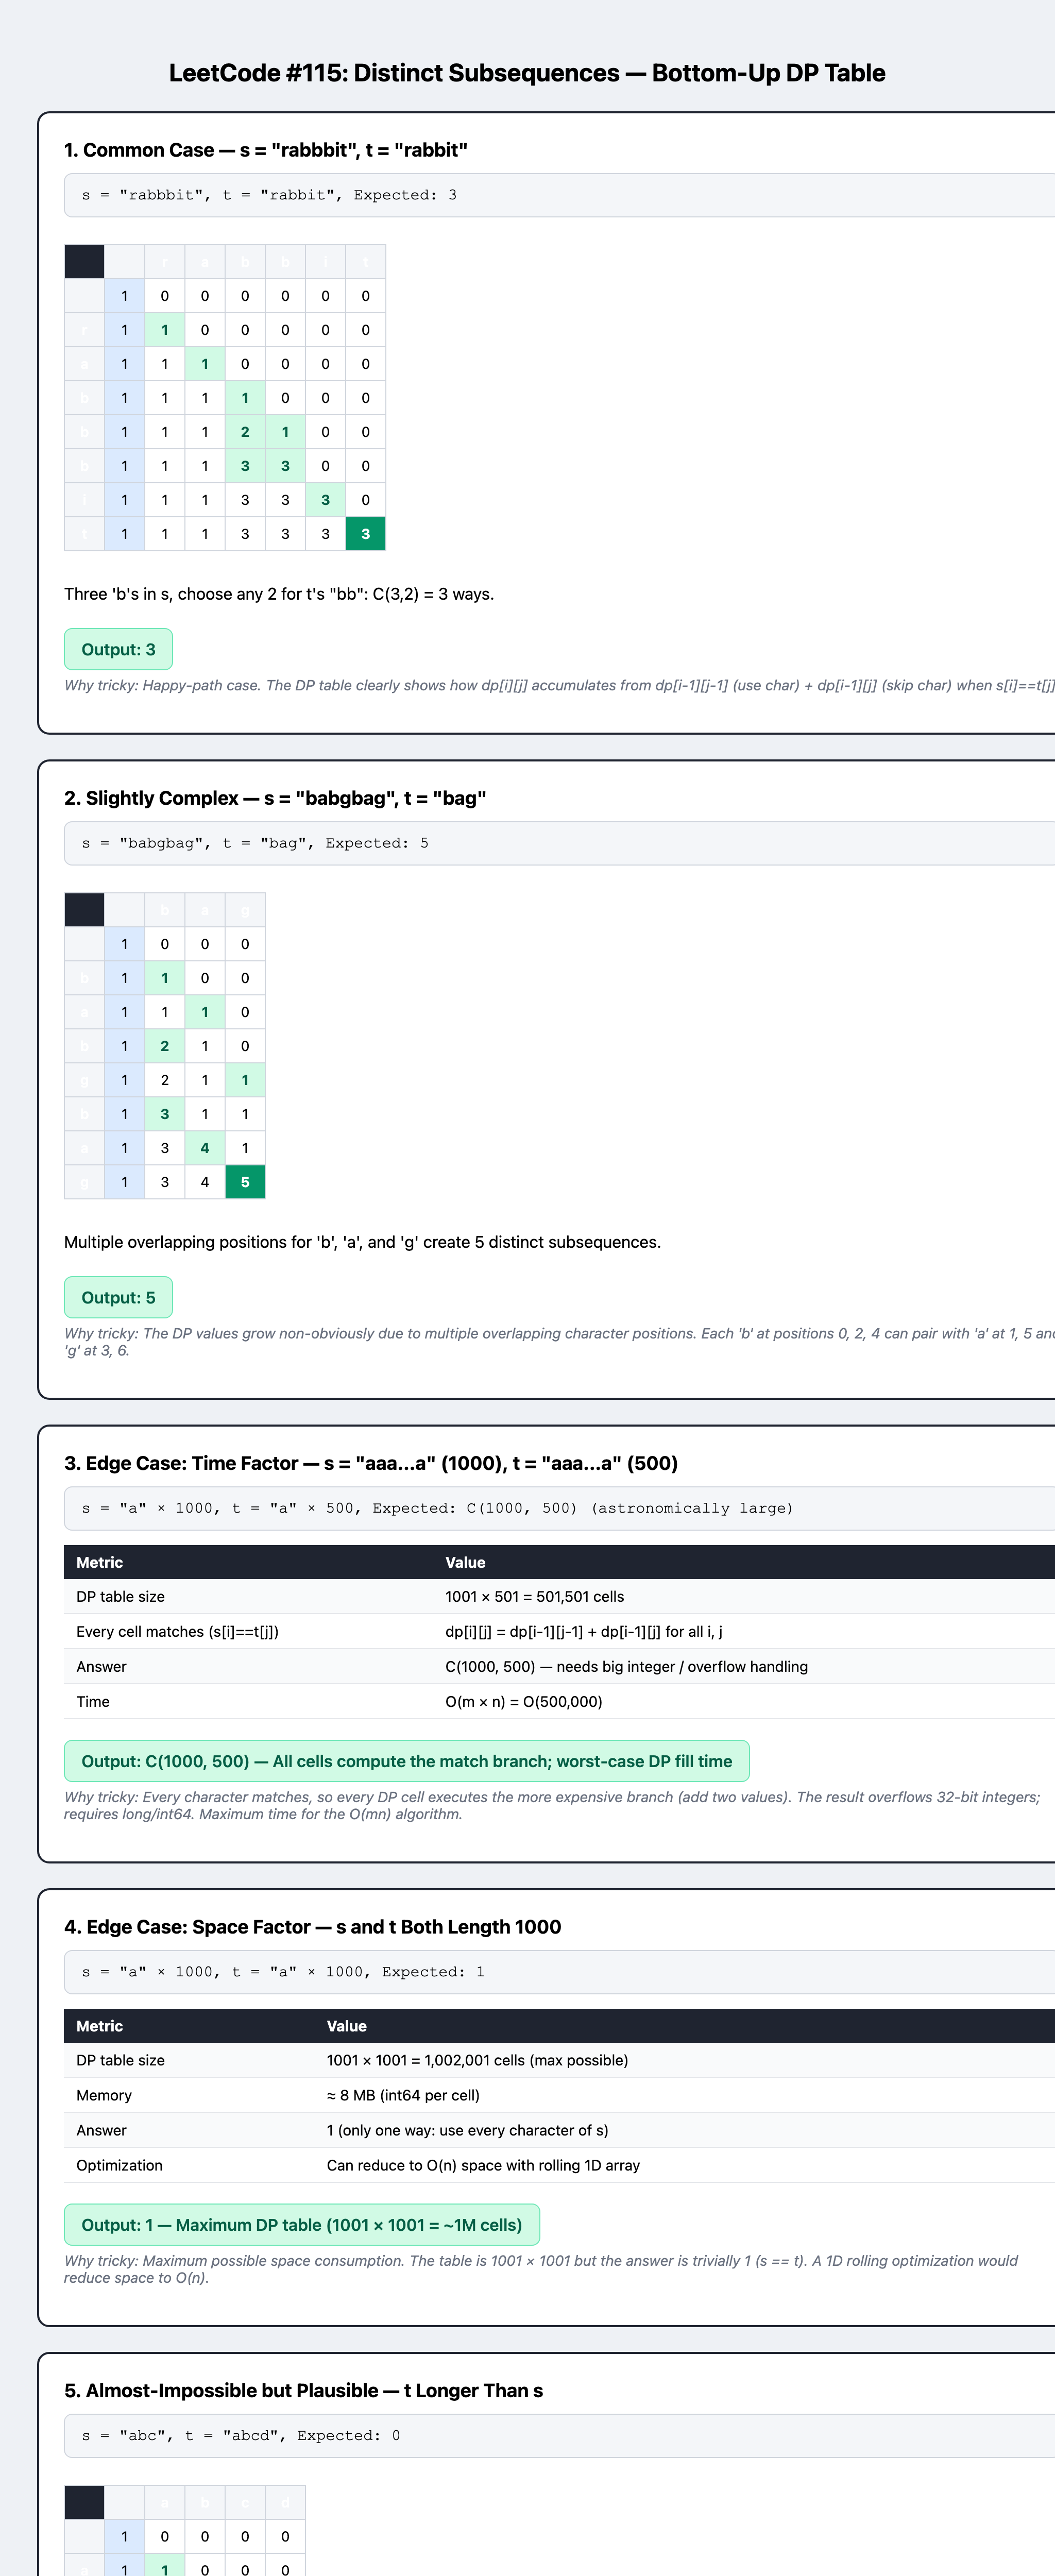